# Titanic Dataset Analysis

**Beginner Python Data Analysis Project**

## 1. Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Read Dataset

In [33]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Check Dataset

In [34]:
df.shape

(891, 12)

In [35]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 4. Check Missing Values

In [37]:
df["Cabin"] = df["Cabin"].fillna("--")
df["Embarked"] = df["Embarked"].fillna("--")

df['Age'] = df['Age'].fillna(df['Age'].median())



In [38]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [39]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,--,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,--,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,--,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,--,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,--,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 5. Check Duplicate Values

In [40]:
df.duplicated().sum()

np.int64(0)

## 6. Basic Statistics

In [41]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 7. Check Survival

In [42]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

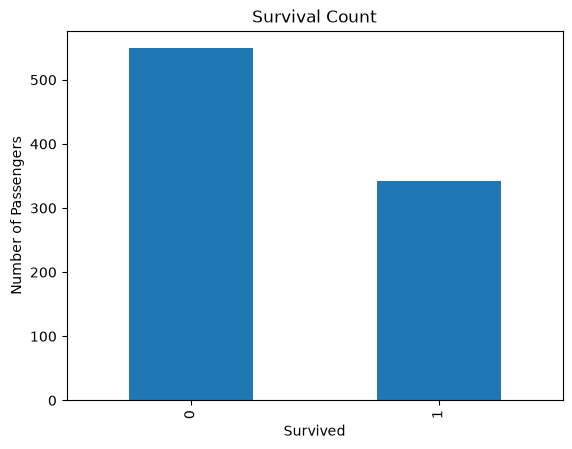

In [43]:
df["Survived"].value_counts().plot(kind="bar")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.title("Survival Count")
plt.show()

## 8. Survival by Gender

In [44]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


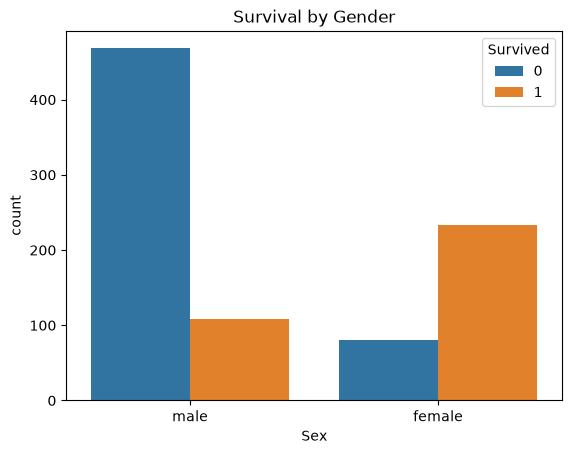

In [45]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

## 9. Survival by Passenger Class

In [46]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


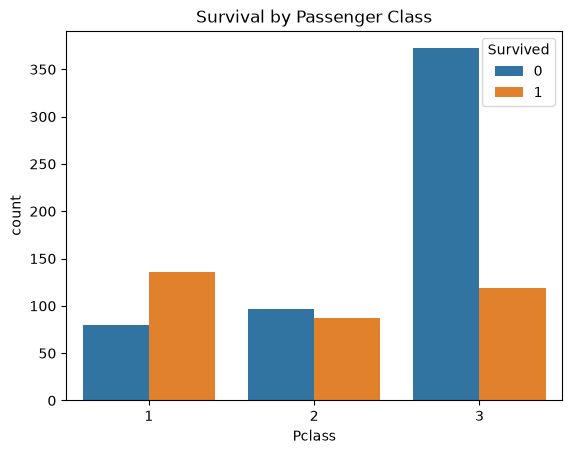

In [47]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

## 10. Age Analysis

In [48]:
df["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

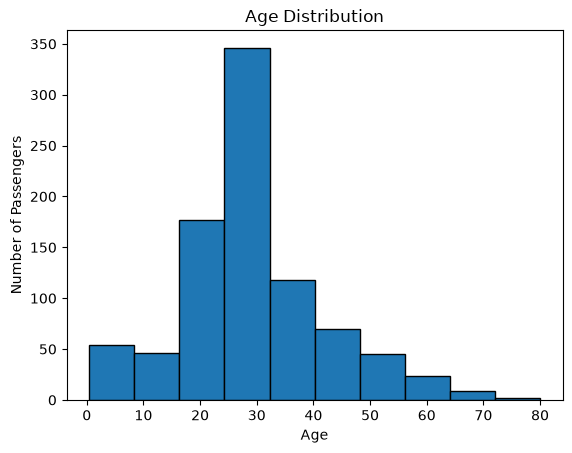

In [58]:
plt.hist(df["Age"].dropna(), bins=10, linewidth=1, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.title("Age Distribution")
plt.show()

## 11. Fare Analysis

In [50]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

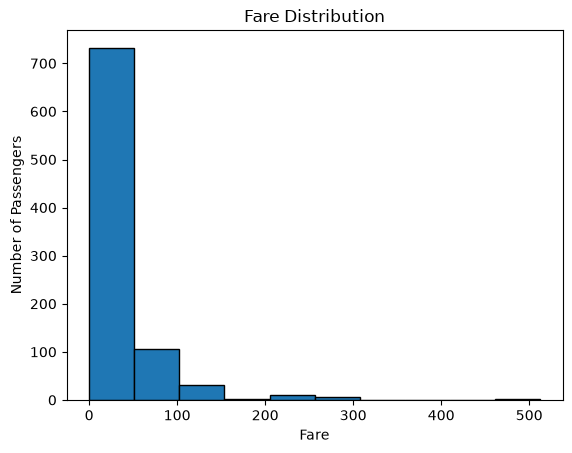

In [59]:
plt.hist(df["Fare"], bins=10, linewidth=1, edgecolor="black")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.title("Fare Distribution")
plt.show()

## 12. Family Size

In [52]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


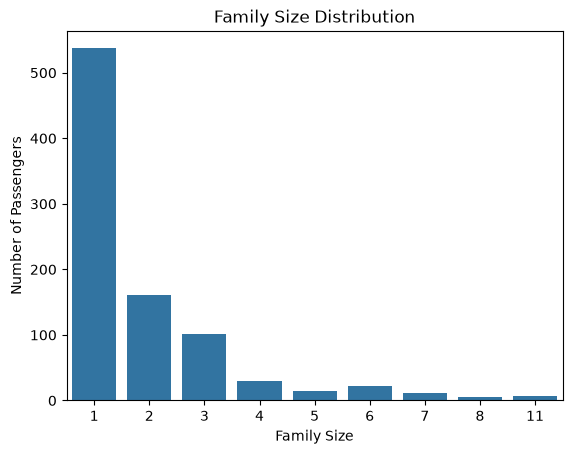

In [53]:
sns.countplot(data=df, x="FamilySize")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.title("Family Size Distribution")
plt.show()

## 13. Correlation

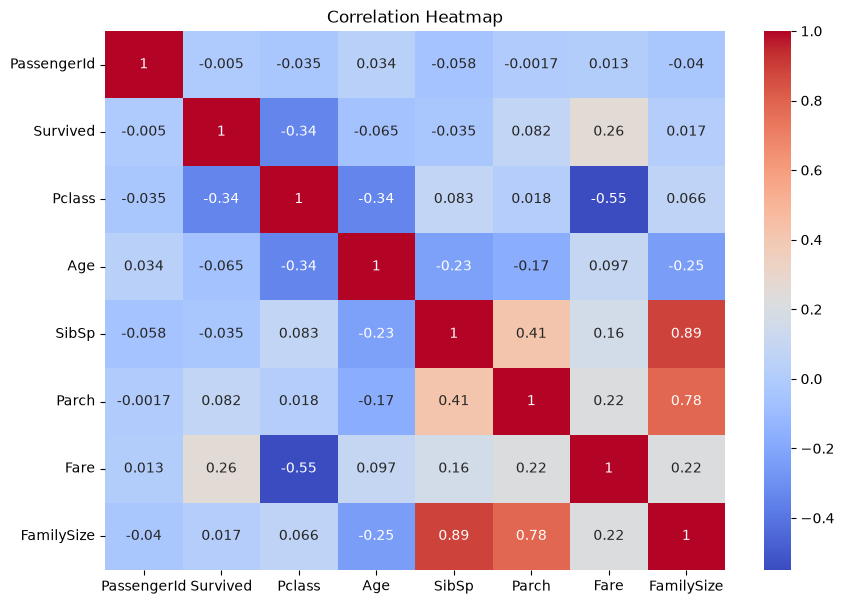

In [54]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 14. Simple Conclusion

In [55]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print("Total Survivors:", df["Survived"].sum())
print("Total Non-Survivors:", (df["Survived"] == 0).sum())
print("\nTitanic dataset analysis completed.")

Total Rows: 891
Total Columns: 13
Total Survivors: 342
Total Non-Survivors: 549

Titanic dataset analysis completed.


## KEY FINDINGS

1. The dataset contains information about 891 Titanic passengers.

2. The dataset has 12 columns containing passenger information such as age, gender, passenger class, fare and survival status.

3. The Survived column shows whether a passenger survived or not.

4. Missing values were checked using isnull().

5. Duplicate records were checked using duplicated().

6. The survival count was analyzed to compare survived and non-survived passengers.

7. Gender was compared with survival to understand the difference between male and female passengers.

8. Passenger class was compared with survival to understand survival across different classes.

9. Age was analyzed using basic statistics and a histogram.

10. Fare was analyzed to understand the distribution of ticket prices.

11. Family size was calculated using SibSp and Parch.

12. A correlation heatmap was created to understand relationships between numerical variables.

13. Different graphs were used to make the Titanic dataset easier to understand.

14. This project helped in learning basic data analysis using Pandas, NumPy, Matplotlib and Seaborn.